**Loan Default Prediction System**


In [1]:
#Import necesassry libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('/content/Loan_default.csv', on_bad_lines='skip', low_memory=False)

In [3]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0.0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0.0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1.0
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0.0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0.0


In [4]:
df.shape

(64686, 18)

In [5]:
df.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [6]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,64686.000000,64686.000000,64686.000000,64686.000000,64686.000000,64686.000000,64686.000000,64686.000000,64686.000000,64685.000000
mean,43.505071,82479.934684,127614.193040,574.555020,59.483752,2.496815,13.518187,36.081625,0.502288,0.116488
std,14.984057,38950.998994,70747.820272,158.535001,34.634721,1.116447,6.638650,16.948051,0.230545,0.320811
min,18.000000,15000.000000,5005.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48836.000000,66338.000000,437.000000,29.000000,2.000000,7.792500,24.000000,0.300000,0.000000
50%,43.000000,82359.500000,127754.500000,574.000000,60.000000,2.000000,13.540000,36.000000,0.500000,0.000000
75%,56.000000,116068.750000,188850.250000,711.000000,89.000000,3.000000,19.260000,48.000000,0.700000,0.000000
max,69.000000,149997.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


Object `default` not found.
Default rate: 11.6%


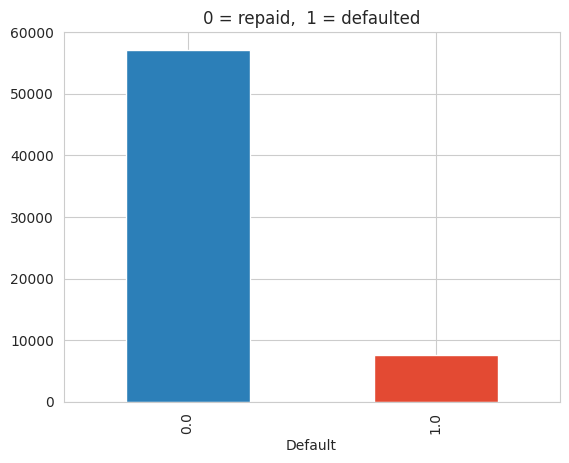

In [7]:
Target balance — what % actually default?
rate = df['Default'].mean()
print(f'Default rate: {rate:.1%}')
df['Default'].value_counts().plot(kind='bar', color=['#2c7fb8','#e34a33'])
plt.title('0 = repaid,  1 = defaulted'); plt.show()

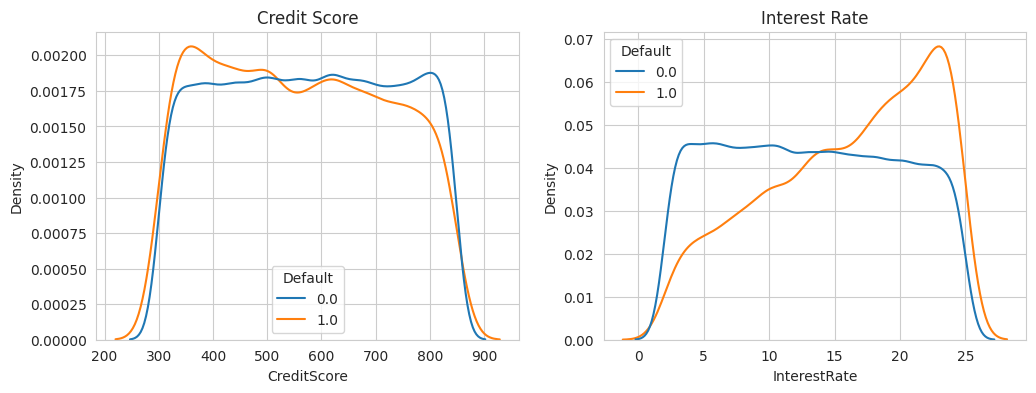

In [8]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

df['CreditScore'] = pd.to_numeric(df['CreditScore'], errors='coerce')

sns.kdeplot(data=df, x='CreditScore', hue='Default', common_norm=False, ax=ax[0])
ax[0].set_title('Credit Score')
sns.kdeplot(data=df, x='InterestRate', hue='Default', common_norm=False, ax=ax[1])
ax[1].set_title('Interest Rate')
plt.show()

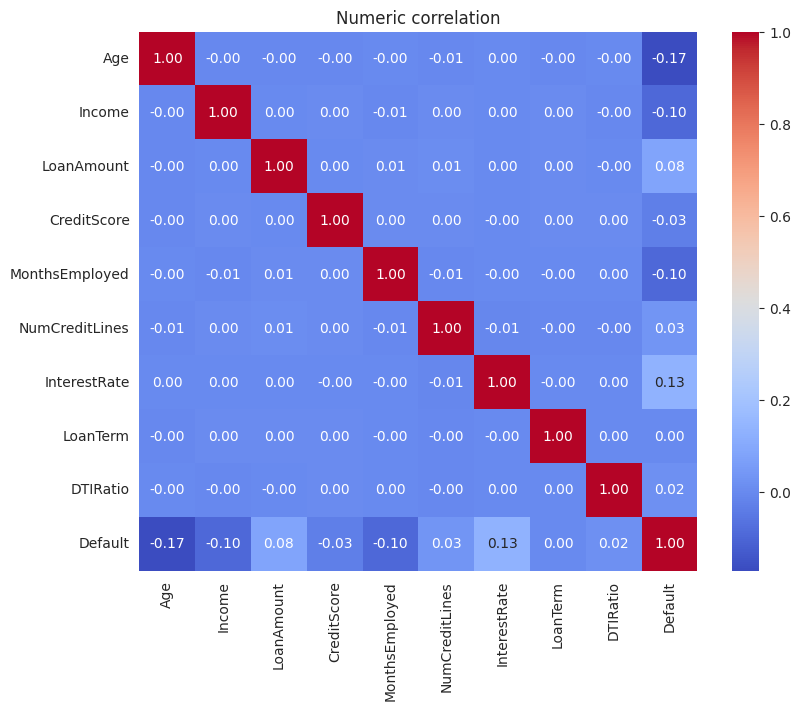

In [9]:
num = ['Age','Income','LoanAmount','CreditScore','MonthsEmployed',
       'NumCreditLines','InterestRate','LoanTerm','DTIRatio']

# Convert all specified numeric columns to numeric type, coercing errors
for col in num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

plt.figure(figsize=(9,7))
sns.heatmap(df[num+['Default']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Numeric correlation')
plt.show()

One-hot encoding

In [10]:
df_enc = pd.get_dummies(df.drop(columns=['LoanID']), drop_first=True)
df_enc = df_enc.dropna(subset=['Default'])
X = df_enc.drop(columns=['Default'])
y = df_enc['Default']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (51748, 24)  Test: (12937, 24)


Check X-list

In [12]:
print(X.columns.tolist())

['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'HasMortgage_Yes', 'HasDependents_Yes', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other', 'HasCoSigner_Yes']


**MODEL BUILDING**

**Logistic Regression**

In [13]:
# Train a Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and binary classification
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
print(f"Logistic Regression F1-Score: {f1_log_reg:.4f}")

Logistic Regression Accuracy: 0.8837
Logistic Regression F1-Score: 0.0079


Logistic Regression Feature Importance

In [14]:
# Feature Importance for Logistic Regression

feature_importance_log = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg_model.coef_[0]
})

# Sort by absolute importance
feature_importance_log['Absolute_Coefficient'] = abs(
    feature_importance_log['Coefficient']
)

feature_importance_log = feature_importance_log.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

feature_importance_log

,Feature,Coefficient,Absolute_Coefficient
0,Age,-3.919448e-02,3.919448e-02
6,InterestRate,2.788991e-02,2.788991e-02
4,MonthsEmployed,-9.442789e-03,9.442789e-03
7,LoanTerm,2.168359e-03,2.168359e-03
5,NumCreditLines,1.156893e-03,1.156893e-03
23,HasCoSigner_Yes,-7.291186e-04,7.291186e-04
18,HasDependents_Yes,-7.057896e-04,7.057896e-04
14,EmploymentType_Unemployed,5.544016e-04,5.544016e-04
15,MaritalStatus_Married,-5.221072e-04,5.221072e-04
3,CreditScore,-5.066536e-04,5.066536e-04


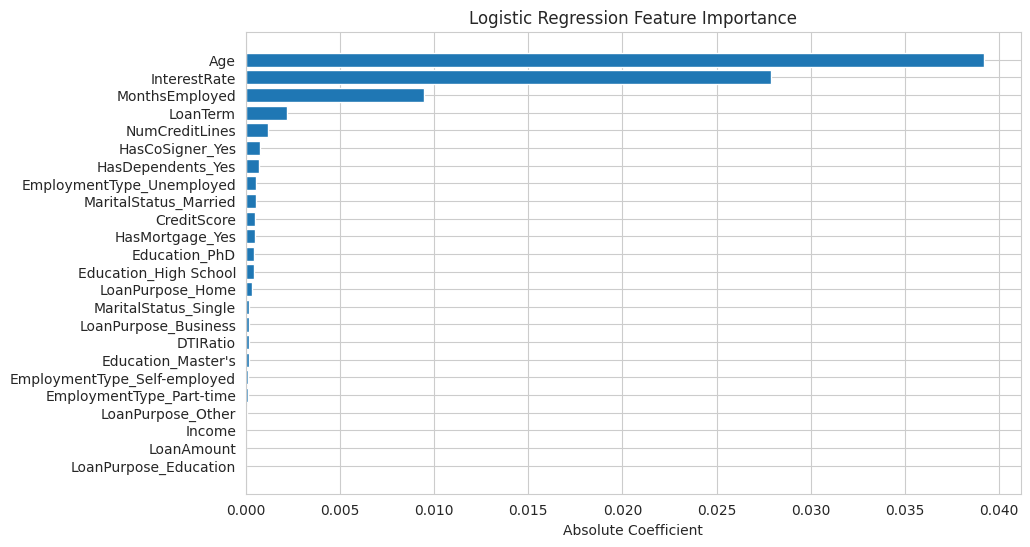

In [15]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_log['Feature'],
    feature_importance_log['Absolute_Coefficient']
)

plt.title("Logistic Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.gca().invert_yaxis()
plt.show()

**Random Forest**

In [16]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f}")

Random Forest Accuracy: 0.8839
Random Forest F1-Score: 0.0092


Random Forest Feature Importance

In [17]:
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

feature_importance_rf

,Feature,Importance
0,Age,0.175949
1,Income,0.160952
6,InterestRate,0.151713
2,LoanAmount,0.114814
4,MonthsEmployed,0.098253
3,CreditScore,0.071019
8,DTIRatio,0.059016
7,LoanTerm,0.022407
5,NumCreditLines,0.021695
23,HasCoSigner_Yes,0.011664


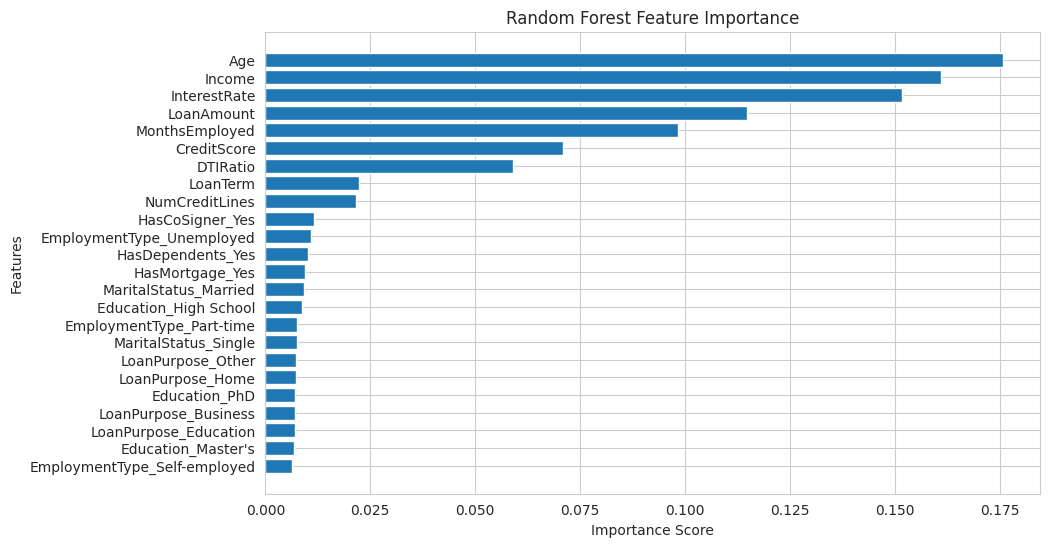

In [18]:
# Random Forest Feature Importance

feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_rf['Feature'],
    feature_importance_rf['Importance']
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.gca().invert_yaxis()
plt.show()

**XGBOOST**

In [19]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost F1-Score: {f1_xgb:.4f}")

XGBoost Accuracy: 0.8874
XGBoost F1-Score: 0.1301


XGBoost Feature Importance

In [20]:
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

feature_importance_xgb

,Feature,Importance
0,Age,0.112622
6,InterestRate,0.069399
1,Income,0.063193
2,LoanAmount,0.050738
4,MonthsEmployed,0.048640
14,EmploymentType_Unemployed,0.048185
18,HasDependents_Yes,0.047913
23,HasCoSigner_Yes,0.045318
15,MaritalStatus_Married,0.042652
9,Education_High School,0.039130


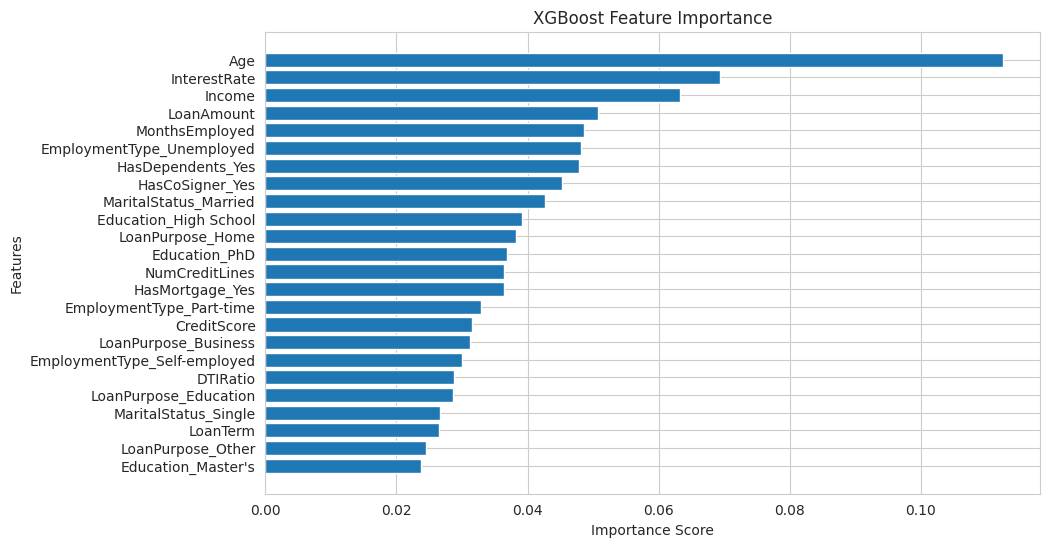

In [21]:
# XGBoost Feature Importance

feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_xgb['Feature'],
    feature_importance_xgb['Importance']
)

plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.gca().invert_yaxis()
plt.show()

**Compare All Three Models**

In [22]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_log_reg,
        accuracy_rf,
        accuracy_xgb
    ],
    'F1 Score': [
        f1_log_reg,
        f1_rf,
        f1_xgb
    ]
})

comparison.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,F1 Score
2,XGBoost,0.887377,0.130149
1,Random Forest,0.883899,0.009235
0,Logistic Regression,0.883744,0.007916


**Visualize the Comparison**

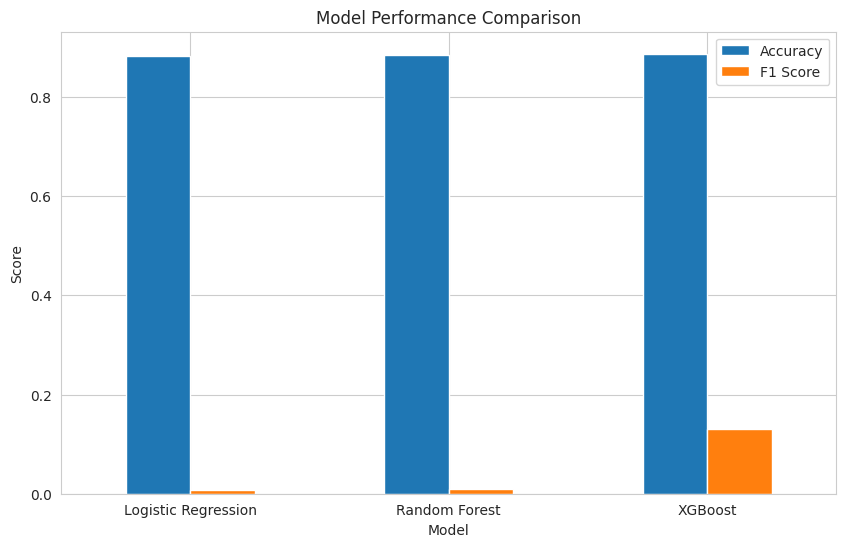

In [23]:
comparison.set_index('Model')[['Accuracy','F1 Score']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

**Select the Best Model Automatically**

In [24]:
best_model_name = comparison.sort_values(
    by='F1 Score',
    ascending=False
).iloc[0]['Model']

print("Best Model:", best_model_name)

Best Model: XGBoost


**Save the Best Model**

In [25]:
import joblib

if best_model_name == "Logistic Regression":
    best_model = log_reg_model

elif best_model_name == "Random Forest":
    best_model = rf_model

else:
    best_model = xgb_model

joblib.dump(best_model, "loan_default_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


**Streamlit Application**

**app.py**

In [31]:
app_py_content = """
import streamlit as st
import joblib
import pandas as pd

# PAGE CONFIGURATION

st.set_page_config(
    page_title="Loan Default Prediction",
    page_icon="💳",
    layout="wide"
)

# LOAD MODEL

model = joblib.load("loan_default_model.pkl")

# CUSTOM CSS

st.markdown('''

''', unsafe_allow_html=True)

# SIDEBAR

with st.sidebar:

    st.image(
        "https://cdn-icons-png.flaticon.com/512/3135/3135715.png",
        width=150
    )

    st.title("📊 Project Overview")

    st.markdown('''
    ### Models Used

    - Logistic Regression
    - Random Forest
    - XGBoost

    ### Objective

    Predict whether a borrower is likely to default on a loan.

    ### Features

    - Real-time prediction
    - Risk probability
    - ML-powered decision support
    ''')

    st.divider()

    st.info(
        "Built with Streamlit, Scikit-Learn and XGBoost."
    )

# HEADER

st.markdown(
    "💳 Loan Default Prediction System",
    unsafe_allow_html=True
)

st.markdown(
    "Machine Learning Powered Credit Risk Assessment Dashboard",
    unsafe_allow_html=True
)

st.divider()

# INPUT SECTION

col1, col2, col3 = st.columns(3)

with col1:

    Age = st.number_input(
        "Age",
        min_value=18,
        max_value=100,
        value=30
    )

    Income = st.number_input(
        "Income",
        min_value=1000,
        value=50000
    )

    LoanAmount = st.number_input(
        "Loan Amount",
        min_value=1000,
        value=10000
    )

with col2:

    CreditScore = st.number_input(
        "Credit Score",
        min_value=300,
        max_value=850,
        value=650
    )

    InterestRate = st.number_input(
        "Interest Rate (%)",
        min_value=1.0,
        max_value=40.0,
        value=10.0
    )

    LoanTerm = st.number_input(
        "Loan Term (Months)",
        min_value=6,
        max_value=360,
        value=36
    )

with col3:

    MonthsEmployed = st.number_input(
        "Months Employed",
        min_value=0,
        value=24
    )

    NumCreditLines = st.number_input(
        "Number of Credit Lines",
        min_value=0,
        value=5
    )

    DTIRatio = st.number_input(
        "Debt-to-Income Ratio",
        min_value=0.0,
        max_value=1.0,
        value=0.30
    )

# PREDICTION

if st.button("🔍 Predict Loan Risk"):

    # Create a dictionary for the input features
    input_dict = {
        'Age': [Age],
        'Income': [Income],
        'LoanAmount': [LoanAmount],
        'CreditScore': [CreditScore],
        'MonthsEmployed': [MonthsEmployed],
        'NumCreditLines': [NumCreditLines],
        'InterestRate': [InterestRate],
        'LoanTerm': [LoanTerm],
        'DTIRatio': [DTIRatio]
    }

    # Create a DataFrame from the input dictionary
    input_data_df = pd.DataFrame(input_dict)

    # Get the column names from the training data X
    # This list is obtained from the kernel state's 'X' variable.
    expected_columns = [
        'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
        'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
        'Education_High School', "Education_Master's", 'Education_PhD',
        'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Un' 
        'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single',
        'HasMortgage_Yes', 'HasDependents_Yes', 'LoanPurpose_Business',
        'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other',
        'HasCoSigner_Yes'
    ]

    # Create an empty DataFrame with all expected columns
    final_input_df = pd.DataFrame(columns=expected_columns)

    # Populate the known numeric features
    for col in input_data_df.columns:
        if col in final_input_df.columns:
            final_input_df[col] = input_data_df[col]

    # Fill all other columns (categorical one-hot encoded) with 0
    for col in final_input_df.columns:
        if col not in input_data_df.columns:
            final_input_df[col] = 0

    # Ensure the order of columns matches the training data 'X'
    final_input_df = final_input_df[expected_columns]

    prediction = model.predict(final_input_df)[0]

    probability = model.predict_proba(
        final_input_df
    )[0][1]

    st.divider()

    st.subheader("Prediction Result")

    colA, colB = st.columns(2)

    with colA:

        if prediction == 1:

            st.error(
                f'''
                ⚠️ HIGH DEFAULT RISK

                Probability of Default:
                {probability:.2%}
                '''
            )

        else:

            st.success(
                f'''
                ✅ LOW DEFAULT RISK

                Confidence:
                {(1-probability):.2%}
                '''
            )

    with colB:

        st.metric(
            "Default Probability",
            f"{probability:.2%}"
        )

        st.progress(float(probability))
    st.metric(
        "Risk Level",
        "High Risk" if prediction == 1 else "Low Risk"
    )

# FOOTER

st.divider()

st.caption(
    "Loan Default Prediction Dashboard | Machine Learning Project"
)
"""

with open("app.py", "w") as f:
    f.write(app_py_content)

print("app.py has been created successfully!")

app.py has been created successfully!


In [32]:
with open("app.py") as f:
    content = f.read()

start = content.find("expected_columns = [")
end = content.find("]", start) + 1
print(content[start:end])

expected_columns = [
        'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
        'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
        'Education_High School', "Education_Master's", 'Education_PhD',
        'EmploymentType_Part-time', 'EmploymentType_Self-employed', 
        'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single',
        'HasMortgage_Yes', 'HasDependents_Yes', 'LoanPurpose_Business',
        'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other',
        'HasCoSigner_Yes'
    ]


Generate **requirement.txt**

In [27]:
import pkg_resources

# Get a list of installed packages and their versions
installed_packages = {d.project_name: d.version for d in pkg_resources.working_set}

required_packages = [
    'streamlit',
    'pandas',
    'joblib',
    'scikit-learn',
    'xgboost',
    'matplotlib',
    'seaborn'
]

# Create the requirements.txt content
requirements_content = []
for pkg in required_packages:
    if pkg in installed_packages:
        requirements_content.append(f"{pkg}=={installed_packages[pkg]}")
    else:
        print(f"Warning: Package '{pkg}' not found in installed packages. Please ensure it's installed.")

# Write to requirements.txt file
with open("requirements.txt", "w") as f:
    f.write("\n".join(requirements_content))

print("requirements.txt has been created successfully!")

requirements.txt has been created successfully!


/tmp/ipykernel_600/2505640248.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
